# 3D Segmentation

> Tutorial 3D Segmentation: This tutorial provides a comprehensive, step-by-step guide to using the bioMONAI platform for nuclei segmentation in histopathology images.
> The dataset has been announced in the paper "Segmentation of Nuclei in Histopathology Images by deep regression of the distance map" in Transaction on Medical Imaging 2019.

In [1]:
#| default_exp tutorial_3dseg

### Setup imports

In [2]:
from bioMONAI.data import *
from bioMONAI.transforms import *
from bioMONAI.core import *
from bioMONAI.core import Path
from bioMONAI.data import get_images, get_target, RandomSplitter
from bioMONAI.losses import *
from bioMONAI.losses import SSIMLoss
from bioMONAI.metrics import *
from bioMONAI.datasets import download_files


In [3]:
import warnings
warnings.filterwarnings("ignore")


In [4]:
device = get_device()
print(device)

cuda


### Download Data

In the next cell, we will download the dataset required for this tutorial. The dataset is hosted online, and we will use the `download_file` function from the `bioMONAI` library to download and extract the files. 

>- You can change the `output_directory` variable to specify a different directory where you want to save the downloaded files.
>- The `url` variable contains the link to the dataset. If you have a different dataset, you can replace this URL with the link to your dataset.
>- By default, we are downloading only the first two images. You can modify the code to download more images if needed.

Make sure you have enough storage space in the specified directory before downloading the dataset.

In [5]:
# Specify the directory where you want to save the downloaded files
output_directory = "../_data/HL60"
output_dirs = ['LowNoise_C00',
               'LowNoise_C25',
               'LowNoise_C50',
               'LowNoise_C75',
               'HighNoise_C00',
               'HighNoise_C25',
               'HighNoise_C50',
               'HighNoise_C75']
output_dirs = [Path(output_directory)/d for d in output_dirs]
# Define the URLs for the dataset
urls = ['https://datasets.gryf.fi.muni.cz/cytometry2009/HL60_LowNoise_C00_3D_TIFF.zip',
        'https://datasets.gryf.fi.muni.cz/cytometry2009/HL60_LowNoise_C25_3D_TIFF.zip',
        'https://datasets.gryf.fi.muni.cz/cytometry2009/HL60_LowNoise_C50_3D_TIFF.zip',
        'https://datasets.gryf.fi.muni.cz/cytometry2009/HL60_LowNoise_C75_3D_TIFF.zip',
        'https://datasets.gryf.fi.muni.cz/cytometry2009/HL60_HighNoise_C00_3D_TIFF.zip',
        'https://datasets.gryf.fi.muni.cz/cytometry2009/HL60_HighNoise_C25_3D_TIFF.zip',
        'https://datasets.gryf.fi.muni.cz/cytometry2009/HL60_HighNoise_C50_3D_TIFF.zip',
        'https://datasets.gryf.fi.muni.cz/cytometry2009/HL60_HighNoise_C75_3D_TIFF.zip']

# download_files(urls, output_dirs, extract=True, extract_dir='.')

### Prepare Data for Training

In the next cell, we will prepare the data for training. We will specify the path to the training images and define the batch size and patch size. Additionally, we will apply several transformations to the images to augment the dataset and improve the model's robustness.

- `X_path`: The path to the directory containing the low-resolution training images.
- `bs`: The batch size, which determines the number of images processed together in one iteration.
- `patch_size`: The size of the patches to be extracted from the images.
- `itemTfms`: A list of item-level transformations applied to each image, including random cropping, rotation, and flipping.
- `batchTfms`: A list of batch-level transformations applied to each batch of images, including intensity scaling.
- `get_target_fn`: A function to get the corresponding ground truth images for the low-resolution images.

>You can customize the following parameters to suit your needs:
>- Change the `X_path` variable to point to a different dataset.
>- Adjust the `bs` and `patch_size` variables to match your hardware capabilities and model requirements.
>- Modify the transformations in `itemTfms` and `batchTfms` to include other augmentations or preprocessing steps.

After defining these parameters and transformations, we will create a `BioDataLoaders` object to load the training and validation datasets.

In [6]:
from fastai.vision.all import parent_label

In [7]:
img_paths = get_images(output_directory,'HighNoise*', filename_filter='*final*.tif')
# create a function to get the target path from the image path
get_target_fn_denoising = get_target('', same_filename=True, relative_path=True, map_foldername=True, target_folder_prefix="LowNoise", signal_folder_prefix="HighNoise")
get_target_fn_seg = get_target('', same_filename=False, same_foldername=True, target_file_prefix='label', signal_file_prefix='final')
# Check that the functions work as expected
print('input:', img_paths[0], '\ntarget:', get_target_fn_denoising(img_paths[0]), '\nmask:', get_target_fn_seg(img_paths[0]), '\nlabel:', parent_label(img_paths[0]))

input: ../_data/HL60/HighNoise_C25/image-final_0004.tif 
target: ../_data/HL60/LowNoise_C25/image-final_0004.tif 
mask: ../_data/HL60/HighNoise_C25/image-label_0004.tif 
label: HighNoise_C25


In [8]:
# build a dataframe with the image paths, target paths, mask paths and labels
from bioMONAI.datasets import build_csv
build_csv(img_paths, 
          get_target_fn_denoising, 
          get_target_fn_seg, 
          parent_label,
          function_names=['target', 'mask', 'label'], 
          output_csv=Path(output_directory)/'all_dataset.csv',
          split=True,
          split_kwargs={'train_fraction': 0.7, 
                        'valid_fraction': 0.2, 
                        'add_is_valid': True, 
                        'random_seed': 42, 
                        'data_save_path': Path(output_directory)})

Train set saved to '../_data/HL60/train.csv'.
Test set saved to '../_data/HL60/test.csv'.
'is_valid' column added to '../_data/HL60/train.csv' for validation samples.


In [29]:
patch_size = (64,64)
n_channels = 1
data_ops = {
    'fn_col': ['filename'],
    'label_col': ['label'],
    'valid_col': ['is_valid'],
    'seed': 42, 
    'bs': 16,
    'img_cls': BioImageProject,
    'item_tfms': [Resample(8),
                  RandCropND(patch_size),
                # RandRot90(prob=.75, spatial_axes=(1,2)), 
                RandFlip(prob=0.75, ndim=2)],
    'batch_tfms': [],   # batch transformations 
}

data = BioDataLoaders.class_from_csv(
    '',
    output_directory + '/train.csv',
    show_summary=False,
    **data_ops,
    )

# print length of training and validation datasets
print('train images:', len(data.train_ds.items), '\nvalidation images:', len(data.valid_ds.items))

train images: 83 
validation images: 24


### Visualize a Batch of Training Data

In the next cell, we will visualize a batch of training data to get an idea of what the images look like after applying the transformations. This step is crucial to ensure that the data augmentation and preprocessing steps are working as expected.

- `data.show_batch(cmap='magma')`: This function will display a batch of images from the training dataset using the 'magma' colormap.

> Change the `cmap` parameter to use a different colormap (e.g., 'gray', 'viridis', 'plasma') based on your preference.

Visualizing the data helps in understanding the dataset better and ensures that the transformations are applied correctly.

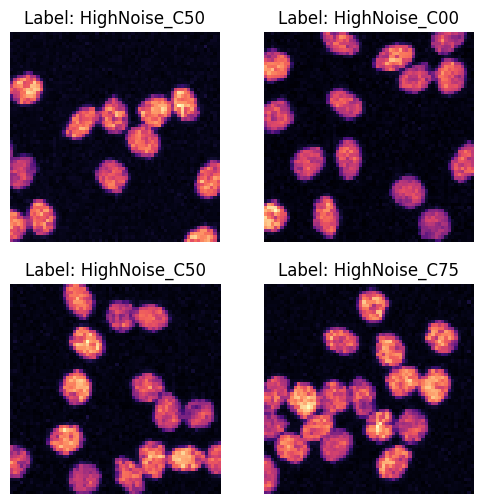

In [30]:
data.show_batch(max_n=4,cmap='magma')

### Define and Train the Model



In [31]:
from bioMONAI.nets import create_unet_model, resnet34
# model = create_unet_model(resnet34, 1, patch_size[1:], True, n_in=n_channels, cut=None, blur_final=True, self_attention=False)
model_classification = resnet34

In [32]:
from fastai.vision.all import CrossEntropyLossFlat, accuracy
loss = CrossEntropyLossFlat()
metrics = accuracy

trainer_classification = visionTrainer(data, model_classification, loss_fn=loss, metrics=metrics, show_summary=False)

epoch,train_loss,valid_loss,accuracy,time


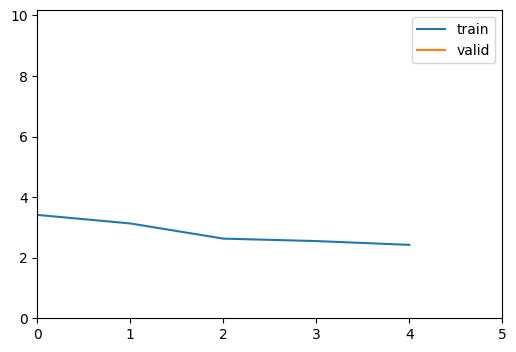

epoch,train_loss,valid_loss,accuracy,time
0,2.033751,4.116651,0.291667,00:28
1,1.918185,7.607526,0.041667,00:29
2,1.902751,3.586475,0.416667,00:29
3,1.857363,1.954902,0.250000,00:29
4,1.704780,1.310891,0.416667,00:29


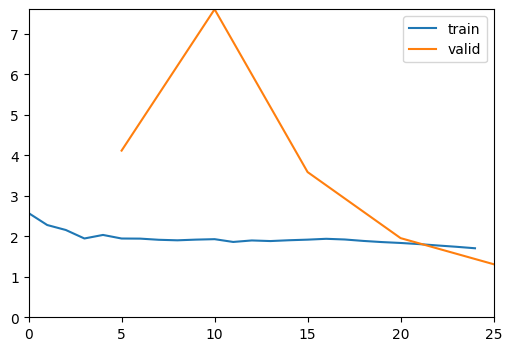

In [33]:
trainer_classification.fine_tune(5, freeze_epochs=1)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [98.0..213.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [97.0..214.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [97.0..219.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [98.0..217.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [98.0..217.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [98.0..223.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [98.0..220.0].
Clipping input data to the valid range for imshow with 

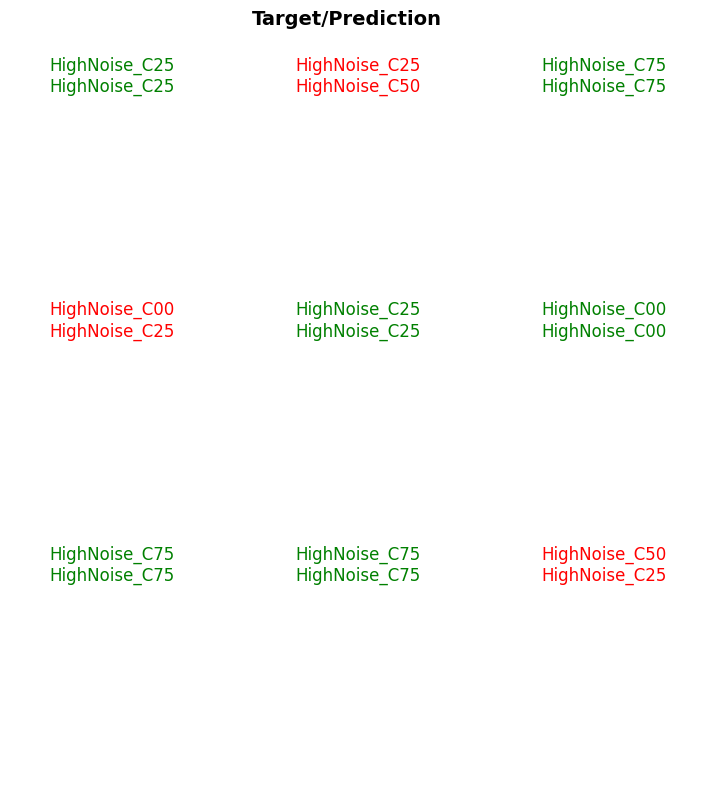

In [35]:
trainer_classification.show_results(cmap='magma')

In [ ]:
from fastai.vision.all import BCEWithLogitsLossFlat
from bioMONAI.metrics import DiceMetric

loss = BCEWithLogitsLossFlat()

metrics = [DiceMetric(include_background=False)]

trainer = fastTrainer(data, model, loss_fn=loss, metrics=metrics, show_summary=False)

In [ ]:
# trainer.fit_one_cycle(50, 1e-3)
trainer.fine_tune(50, freeze_epochs=2)

### Show Results

In the next cell, we will visualize the results of the trained model on a batch of validation data. This step helps in understanding how well the model has learned to denoise the images.

- `trainer.show_results(cmap='magma')`: This function will display a batch of images from the validation dataset along with their corresponding denoised outputs using the 'magma' colormap.

Visualizing the results helps in assessing the performance of the model and identifying any areas that may need further improvement.

In [ ]:
trainer.show_results(cmap='magma')

### Save the Trained Model

In the next cell, we will save the trained model to a file. This step is crucial to preserve the model's weights and architecture, allowing you to load and use the model later without retraining it.

- `trainer.save('tmp-model')`: This function saves the model to a file named 'tmp-model'. You can change the filename to something more descriptive based on your project.

> Suggestions for customization:
>- Change the filename to include details like the model architecture, dataset, or date (e.g., 'unet_resnet34_U2OS_2023').
>- Save the model in a specific directory by providing the full path (e.g., 'models/unet_resnet34_U2OS_2023').
>- Save additional information like training history, metrics, or configuration settings in a separate file for better reproducibility.

Saving the model ensures that you can easily share it with others or deploy it in a production environment without needing to retrain it.

In [ ]:
# trainer.save('tmp-model')

### Evaluate the Model on Test Data

In the next cell, we will evaluate the performance of the trained model on unseen test data. This step is crucial to get an unbiased evaluation of the model's performance and understand how well it generalizes to new data.

- `test_X_path`: The path to the directory containing the low-resolution test images.
- `test_data`: A `DataLoader` object created from the test images.
- `evaluate_model(trainer, test_data, metrics=SSIMMetric(2))`: This function evaluates the model on the test dataset using the specified metrics (in this case, SSIM).

> Suggestions for customization:
>- Change the `test_X_path` variable to point to a different test dataset.
>- Add more metrics to the `metrics` parameter to get a comprehensive evaluation (e.g., `MSEMetric()`, `MAEMetric()`).
>- Save the evaluation results to a file for further analysis or reporting.

Evaluating the model on test data helps in understanding its performance in real-world scenarios and identifying any areas that may need further improvement.

In [ ]:
test_data = test_biodataloader(data, output_directory + '/patches_test.csv')
# print length of test dataset
print('test images:', len(test_data.items))

evaluate_model(trainer, test_data, metrics=[SSIMMetric(2)]);